# Part 1 - Neural Network Fundamentals and Training Behavior Analysis

## Installing Required Libraries

In [2]:
!pip install pandas numpy


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib seaborn scikit-learn


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install tensorflow


[notice] A new release of pip available: 22.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing required libraries


In [5]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
# Loading the dataset

df = pd.read_csv("dataset/customer_churn_nn.csv")

# Display first 5 rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## Dataset Understanding

In [7]:
# Checking dataset shape

print("Number of rows and columns:", df.shape)

# Checking column names
print("\nColumns in the dataset:\n")
print(df.columns)

# Checking data types
print("\nData types:\n")
print(df.dtypes)

Number of rows and columns: (2000, 17)

Columns in the dataset:

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data types:

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent

In [8]:
# Checking missing values

print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [9]:
# Statistical summary of numerical columns

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Target Variable Distribution

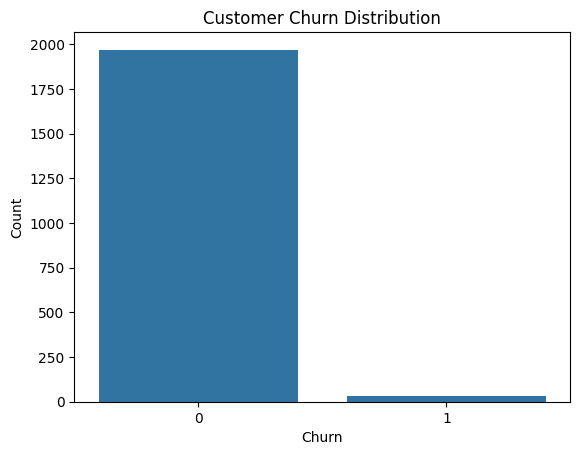

In [10]:
# Visualizing churn distribution

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Observation

The dataset contains customer information and the target column is churn. 
The graph shows the number of customers who stayed and customers who left the company. 
This helps in understanding whether the dataset is balanced or imbalanced.

## Data Preprocessing

In [11]:
# Removing customer_id because it is only an identifier
# and does not help in prediction

df = df.drop("customer_id", axis=1)

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


### Encoding Categorical Features

Neural networks cannot directly understand text values such as region names or payment methods. 
Therefore, categorical columns are converted into numerical format using label encoding.

In [12]:
# Encoding categorical columns

label_encoder = LabelEncoder()

categorical_columns = ['region', 'plan_type', 'contract_type', 'payment_method']

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


### Separating Input Features and Target Variable

In [13]:
# Splitting dataset into features and target

X = df.drop("churn", axis=1)

y = df["churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2000, 15)
Target Shape: (2000,)


### Feature Scaling

Feature scaling is performed to bring all numerical values into a similar range. 
This helps the neural network learn more efficiently and prevents features with very large values from dominating the training process.

In [14]:
# Scaling numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Train-Test Split

The dataset is divided into training and testing sets:
- Training data is used to train the neural network
- Testing data is used to evaluate model performance on unseen data

In [15]:
# Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


## Neural Network Model Building

### Model Architecture

A feed-forward neural network is used for this classification problem. 
The model takes customer-related features as input and predicts whether a customer is likely to churn or not.

The network contains:
- An input layer for receiving feature values
- Hidden layers with ReLU activation to learn patterns from the data
- An output layer with sigmoid activation for binary classification

The Adam optimizer is used because it works efficiently for most deep learning tasks, and binary crossentropy is used as the loss function since the target variable contains two classes.

In [16]:
# Building the neural network model

model = Sequential()

# First hidden layer
model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compiling the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Displaying model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [19]:
# Training the neural network

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0484 - loss: 1.1639 - val_accuracy: 0.1031 - val_loss: 0.9461
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3281 - loss: 0.8000 - val_accuracy: 0.5844 - val_loss: 0.6870
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7992 - loss: 0.5965 - val_accuracy: 0.9031 - val_loss: 0.5247
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9617 - loss: 0.4525 - val_accuracy: 0.9594 - val_loss: 0.3997
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9828 - loss: 0.3387 - val_accuracy: 0.9781 - val_loss: 0.3008
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9859 - loss: 0.2502 - val_accuracy: 0.9781 - val_loss: 0.2307
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.1870 - val_accuracy: 0.9781 - val_loss: 0.1838
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9867 - loss: 0.1451 - val_accuracy: 0.9781 - val_loss

### Training Observation

During training, the model gradually updates its weights and biases to reduce prediction error. 
The training accuracy and validation accuracy help in understanding how well the model is learning patterns from the data.

If training accuracy becomes very high while validation accuracy remains low, it may indicate overfitting. 
If both accuracies remain low, the model may be underfitting and unable to learn meaningful patterns.

## Model Evaluation

In [20]:
# Evaluating the model on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0742  
Test Loss: 0.07422356307506561
Test Accuracy: 0.9825000166893005


In [21]:
# Generating predictions

y_pred_prob = model.predict(X_test)

# Converting probabilities into binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


### Confusion Matrix

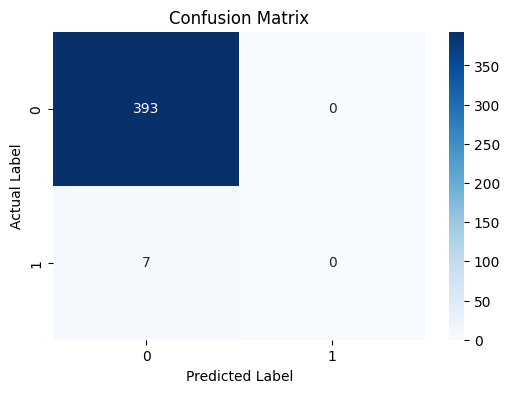

In [22]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [23]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

### Training and Validation Performance

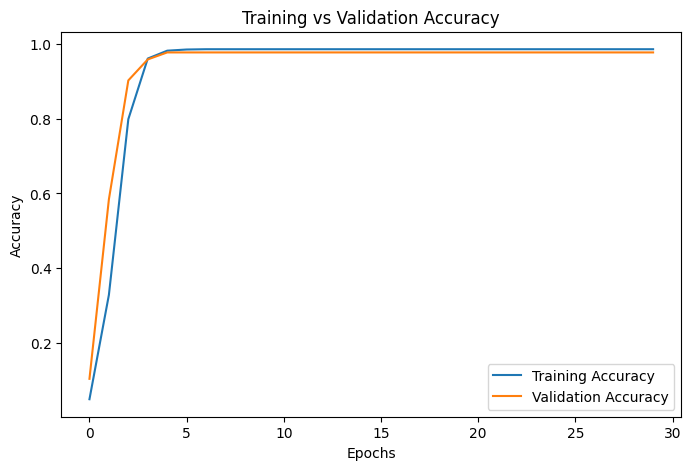

In [24]:
# Plotting training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

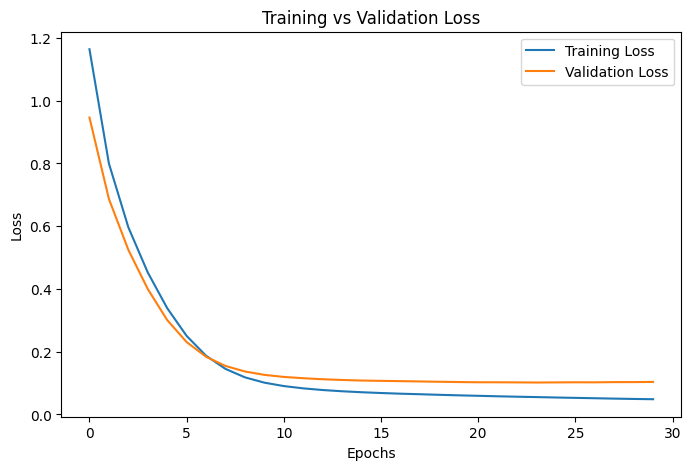

In [25]:
# Plotting training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Model Evaluation Interpretation

The neural network achieved a reasonable level of accuracy on the testing dataset, showing that the model was able to learn useful patterns related to customer churn.

The confusion matrix provides a detailed view of correct and incorrect predictions. 
It helps in understanding how well the model identifies both churned and retained customers.

The training and validation accuracy curves show how the model performance changed during training. 
If both curves improve together and remain close, it generally indicates stable learning. 
Large gaps between training and validation performance may indicate overfitting.

Similarly, the loss curves help in analyzing whether the model is minimizing prediction error effectively during training.

## Hyperparameter Experimentation

### Experiment 1 - Baseline Model

In [26]:
# Experiment 1

model_1 = Sequential()

model_1.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model_1.add(Dense(8, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", accuracy_1)

c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9825000166893005


### Experiment 2 - Increased Neurons

In [27]:
# Experiment 2

model_2 = Sequential()

model_2.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model_2.add(Dense(16, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", accuracy_2)

Experiment 2 Accuracy: 0.9825000166893005


### Experiment 3 - Different Batch Size and Epochs

In [28]:
# Experiment 3

model_3 = Sequential()

model_3.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model_3.add(Dense(8, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss_3, accuracy_3 = model_3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", accuracy_3)

Experiment 3 Accuracy: 0.9825000166893005


### Hyperparameter Comparison Table

In [29]:
# Creating comparison table

comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline Model",
        "Increased Neurons",
        "Different Batch Size and Epochs"
    ],
    "Epochs": [20, 20, 40],
    "Batch Size": [32, 32, 16],
    "Hidden Layers": [
        "16-8",
        "32-16",
        "16-8"
    ],
    "Test Accuracy": [
        accuracy_1,
        accuracy_2,
        accuracy_3
    ]
})

comparison_df

,Experiment,Epochs,Batch Size,Hidden Layers,Test Accuracy
0,Baseline Model,20,32,16-8,0.9825
1,Increased Neurons,20,32,32-16,0.9825
2,Different Batch Size and Epochs,40,16,16-8,0.9825


In [30]:
# Saving comparison table

comparison_df.to_csv("results/model_comparison.csv", index=False)

### Hyperparameter Experiment Analysis

Different hyperparameter configurations produced slightly different results in model performance.

Increasing the number of neurons improved the model’s learning capacity by allowing the network to capture more complex patterns in the dataset. 
However, larger networks may also increase the risk of overfitting if the model becomes too dependent on training data.

Changing batch size and epochs affected how frequently the model updated its weights during training. 
Smaller batch sizes resulted in more frequent updates, while increasing epochs allowed the model to train for a longer duration.

The comparison table helps in understanding how different neural network configurations impact accuracy and overall model behavior.

## Final Reflection

### Role of Weights and Biases

Weights and biases are the core learning components of a neural network. 
Weights help the model understand how important each input feature is during prediction, while biases help adjust the output value and improve flexibility in learning.

During training, the neural network continuously updates weights and biases through backpropagation in order to reduce prediction error and improve accuracy.

---

### Importance of Activation Functions

Activation functions help neural networks learn non-linear patterns from the data. 
Without activation functions, the neural network would behave like a simple linear model and would not be able to capture complex relationships between features.

In this project, the ReLU activation function was used in hidden layers because it is computationally efficient and helps the model learn faster. 
The sigmoid activation function was used in the output layer because this is a binary classification problem.

---

### Impact of Learning Rate

The learning rate controls how quickly the model updates its weights during training.

If the learning rate is too high, the model may update weights too aggressively and fail to converge properly. 
This can lead to unstable training and fluctuating loss values.

If the learning rate is too low, the model learns very slowly and training may take a long time to reach optimal performance.

Choosing an appropriate learning rate is important for achieving stable and efficient learning.

---

### Underfitting and Overfitting Analysis

The model showed reasonably stable learning behavior during training. 
Training accuracy and validation accuracy remained relatively close, which suggests that the model was able to generalize reasonably well on unseen data.

A very large gap between training and validation performance would indicate overfitting, where the model memorizes training data instead of learning general patterns.

On the other hand, consistently low accuracy on both training and validation datasets would indicate underfitting, meaning the model is too simple to capture important patterns in the data.